In [ ]:
!pip install pandas matplotlib seaborn openpyxl


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Superstore.csv', encoding='latin1')

# Show first 5 rows
print("FIRST 5 ROWS")
print(df.head())


FIRST 5 ROWS
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
1       2  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
2       3  CA-2013-138688  13-06-2013  17-06-2013    Second Class    DV-13045   
3       4  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   
4       5  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0      

In [ ]:
print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64

In [ ]:
print("\nCOLUMN NAMES")
print(df.columns)



COLUMN NAMES
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')

In [ ]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

In [ ]:
df['Month'] = df['Order Date'].dt.month_name()

print("\nDATA CLEANING COMPLETED")


DATA CLEANING COMPLETED


In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("\nTOTAL SALES:", total_sales)
print("TOTAL PROFIT:", total_profit)


TOTAL SALES: 2297200.8603000003
TOTAL PROFIT: 286397.0217


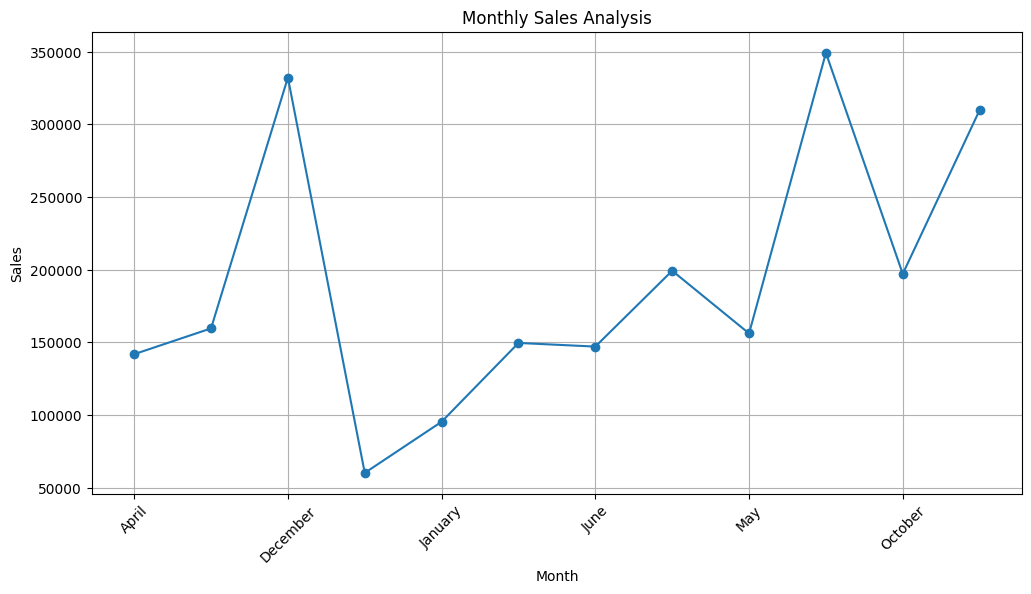

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Analysis')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()


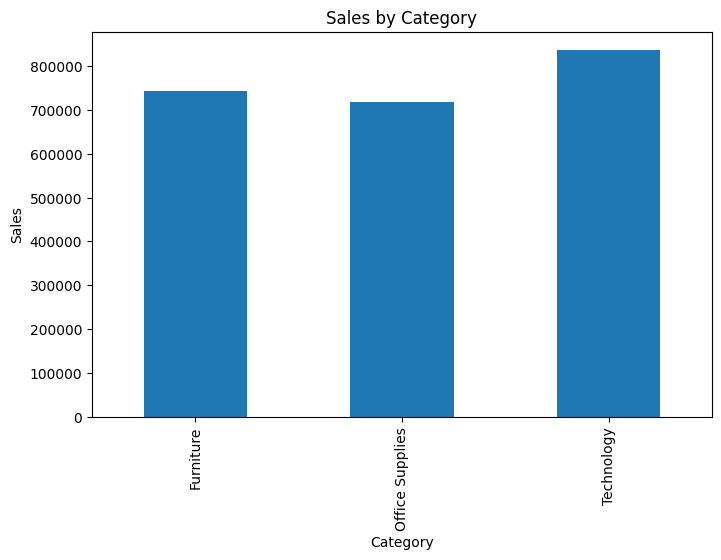

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()


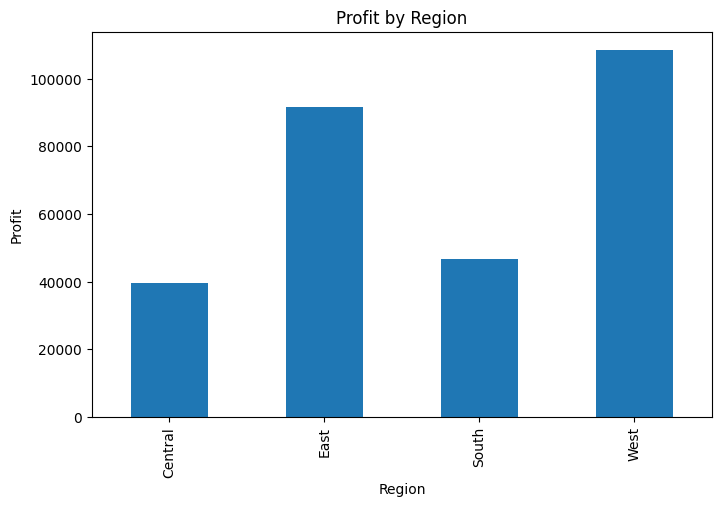

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')

plt.show()



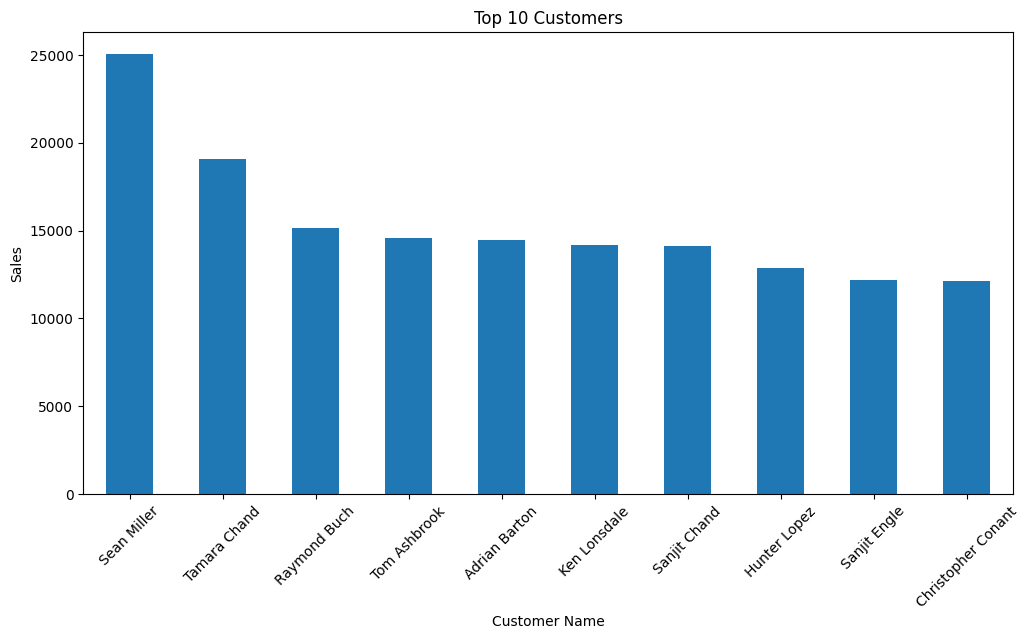

In [ ]:
top_customers = df.groupby('Customer Name')['Sales'].sum() \
                  .sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar')

plt.title('Top 10 Customers')
plt.xlabel('Customer Name')
plt.ylabel('Sales')
plt.xticks(rotation=45)

plt.show()

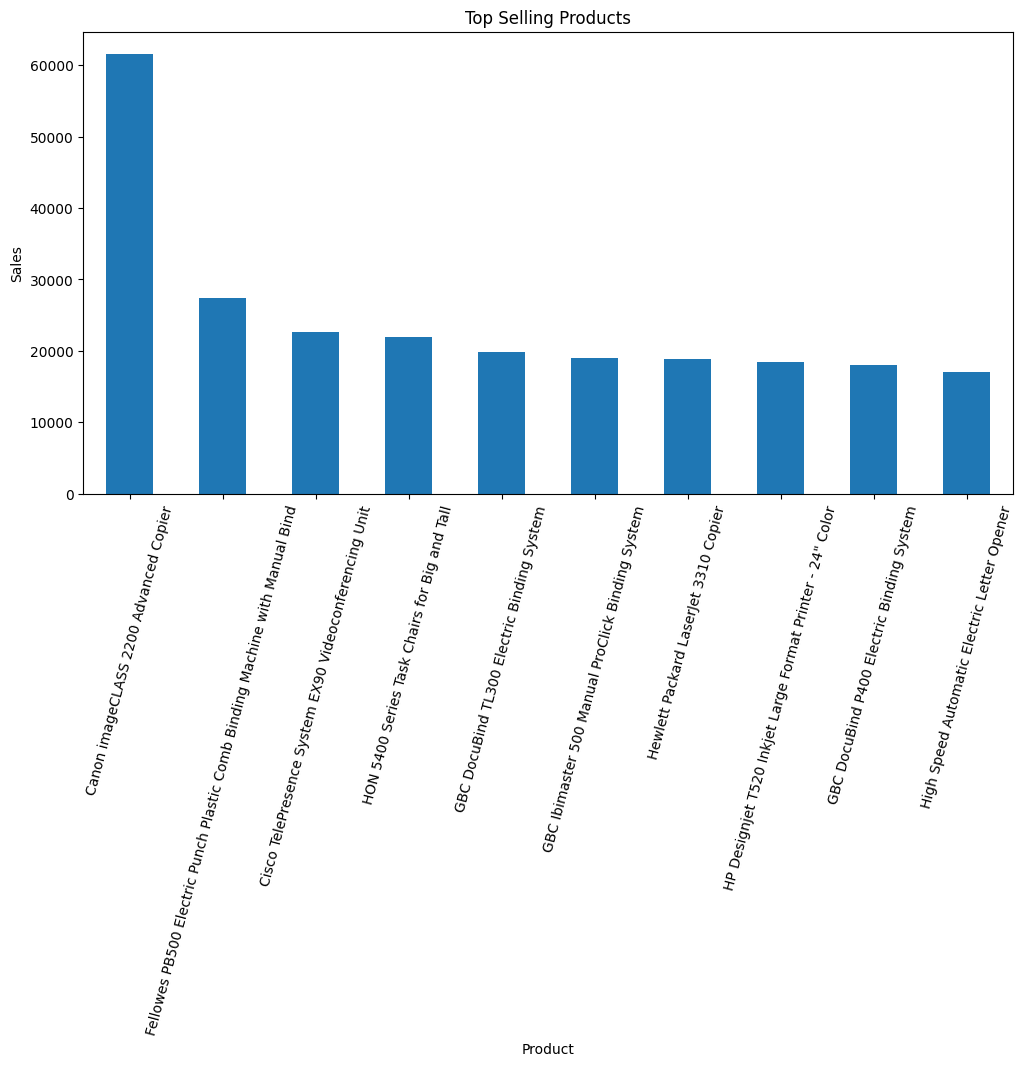

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum() \
                 .sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')

plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=75)

plt.show()


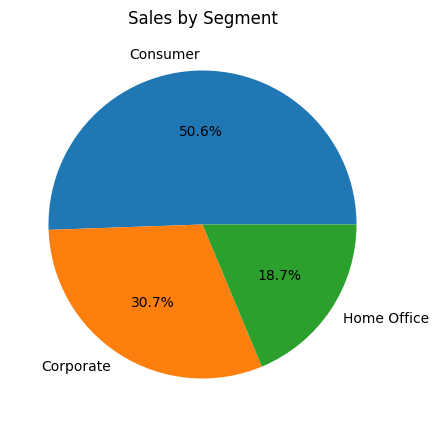

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,5))
segment_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Sales by Segment')
plt.ylabel('')

plt.show()

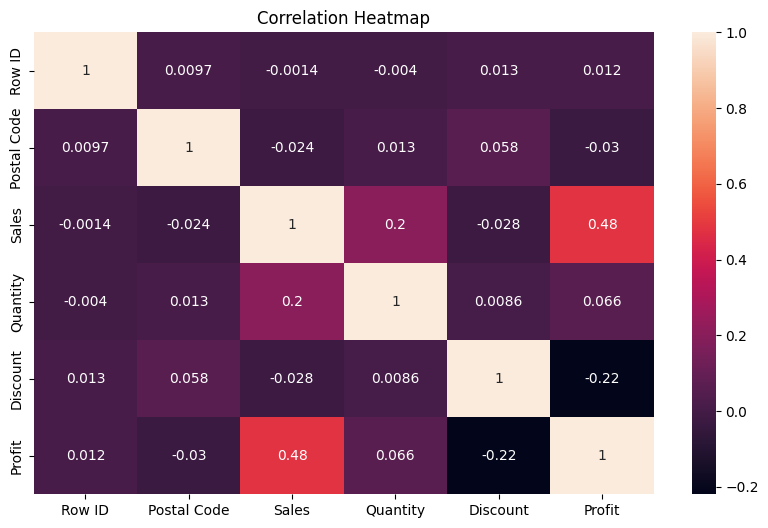

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True)

plt.title('Correlation Heatmap')

plt.show()

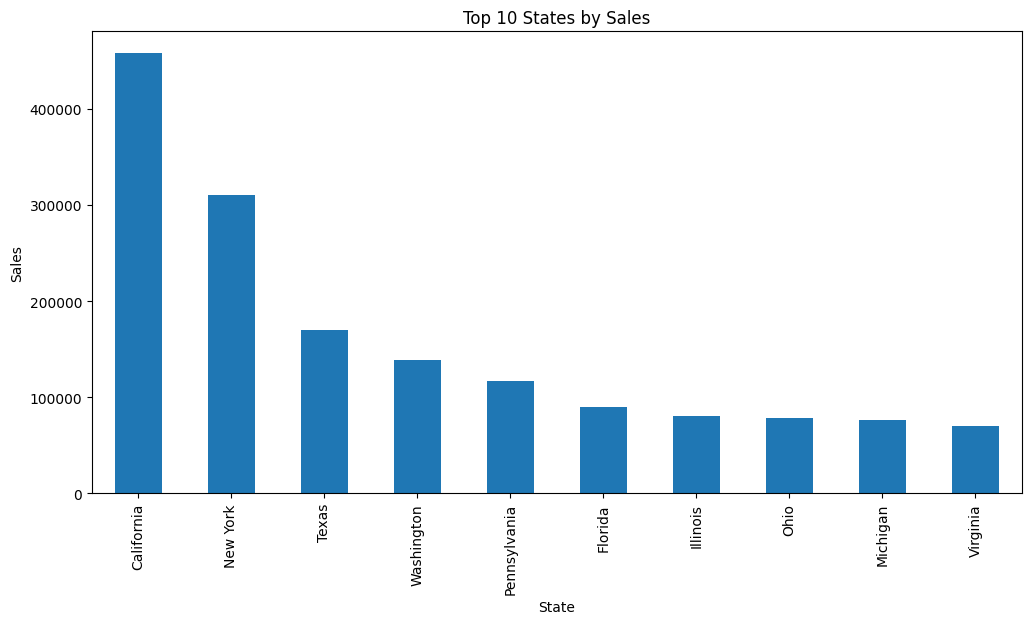

In [ ]:
top_states = df.groupby('State')['Sales'].sum() \
               .sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_states.plot(kind='bar')

plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')

plt.show()

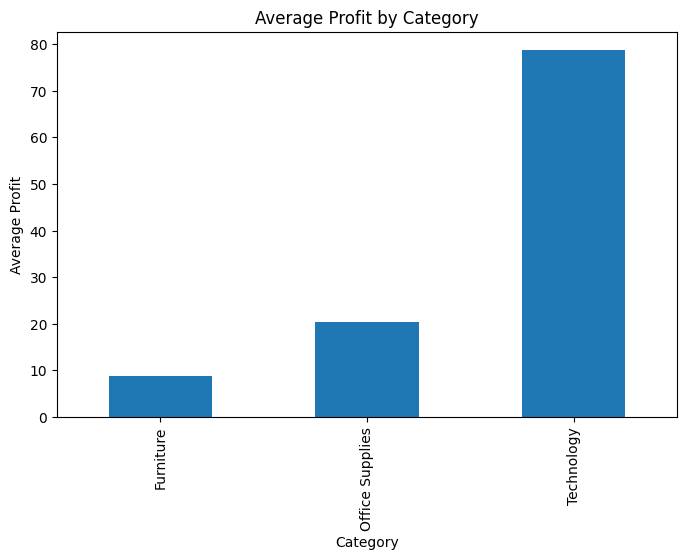

In [ ]:
avg_profit = df.groupby('Category')['Profit'].mean()

plt.figure(figsize=(8,5))
avg_profit.plot(kind='bar')

plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')

plt.show()


In [ ]:
df.to_csv('cleaned_superstore_data.csv', index=False)

print("\nCLEANED DATASET SAVED SUCCESSFULLY")



CLEANED DATASET SAVED SUCCESSFULLY


In [ ]:
print("\n========== FINAL INSIGHTS ==========")

print("\nHighest Sales Category:")
print(category_sales.idxmax())

print("\nMost Profitable Region:")
print(region_profit.idxmax())

print("\nTop Customer:")
print(top_customers.idxmax())

print("\nTop Selling Product:")
print(top_products.idxmax())

print("\nProject Completed Successfully!")


========== FINAL INSIGHTS ==========

Highest Sales Category:
Technology

Most Profitable Region:
West

Top Customer:
Sean Miller

Top Selling Product:
Canon imageCLASS 2200 Advanced Copier

Project Completed Successfully!
